# Simulations (Excel-driven, C++/Python switchable) -- VCEM

Brazilian-disk + crack-network coupling, driven entirely by an Excel
workbook in `vcem/input/`. Replaces the hand-coded
`run_disk_compression_2()` that used to live in this notebook.

## What this notebook does
1. Reads `input/<case>.xlsx` (sheets: BEM, GEOMETRY, CRACK_NETWORK,
   CONFIGURATION_LOGIC, CONFIGURATION_PARAM).
2. Builds typed parameter objects (`BrazilianDiskParams`,
   `CrackGrowthParams`, `PlotParams`, a boundary spec, a grid spec).
3. Runs the disk-compression workflow:
   - BEM baseline solve on the disk
   - One-way crack growth + outer-cycle coupling (iterative or direct)

## Regenerating the template
After defaults change in any dataclass in `fracture_utils.Ubem`, regenerate
the starter workbook with:

    python input/_build_template.py

This will overwrite `input/disk_compression_2.xlsx` -- back up first if
you have hand edits to preserve.

## Grid mesh options (`GEOMETRY.grid_source`)
- `builtin_rect`   : rectangular grid built from `n_grid` + `pad_frac`
                     (this is what `ensure_bem_field` uses for the saved
                     `xs.npy` / `ys.npy` arrays).
- `builtin_polar`  : polar grid (r x theta) for out-of-band stress sampling.
- `external_file`  : load `(N, 2)` `(x, y)` nodes from a `.csv` or `.npy`
                     file (point `grid_external_file` to it).

Only `builtin_rect` is consumed by the BEM contour arrays in the current
disk pipeline. The other two are exposed via
`excel_io.build_grid_points(cfg)` for downstream / postprocessing use.


## 1. Pick the case workbook

In [2]:
# Point this at the .xlsx that describes your run. Relative paths are
# resolved against the repo root (= the vcem/ directory).


CASE_XLSX = "input/disk_compression_data.xlsx"


## 2. Preamble, Excel load, engine setup

Loads the workbook, captures `ENGINE` as a notebook global so the
monkey-patches below pick it up, and reloads / re-patches every
solver-side module that has an `engine='cpp' | 'python'` hook.


In [3]:
from __future__ import annotations

from pathlib import Path
import os, sys
import numpy as np  # noqa: F401
import matplotlib.pyplot as plt  # noqa: F401

nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Hoist preamble.py at module scope so the run function inherits its names.
from preamble import *  # noqa: F401,F403

# --- Load case configuration from Excel ------------------------------
from input.excel_io import load_case, build_grid_points

_xlsx_path = (repo_root / CASE_XLSX).resolve()
cfg = load_case(_xlsx_path)

CASE    = Path(CASE_XLSX).stem
ENGINE  = cfg.engine          # consumed by the monkey-patch block below
DRY_RUN = cfg.dry_run

print(f'Workbook:  {_xlsx_path}')
print(f'Case:      {CASE}')
print(f'Engine:    {ENGINE}')
print(f'Coupling:  {cfg.coupling_method}  |  outer_cycles={cfg.outer_cycles}')
print(f'Network:   {cfg.vertices.shape[0]} vertices, {cfg.connectivity.shape[0]} edges')
print(f'Grid src:  {cfg.grid.source}')

# --- Backend dispatch (re-runnable: no Kernel-Restart needed) --------
import sys as _sys, importlib as _il

# Add vcem/cpp/python so `import bem_cpp` resolves.
_cpp_pkg_dir = str(repo_root / 'cpp' / 'python')
if _cpp_pkg_dir not in _sys.path:
    _sys.path.insert(0, _cpp_pkg_dir)

# Drop any half-baked bem_cpp import from a previous run.
for _stale in [m for m in list(_sys.modules) if m == 'bem_cpp' or m.startswith('bem_cpp.')]:
    del _sys.modules[_stale]
_CPP_AVAILABLE = False
_bem_cpp_err = None
try:
    import bem_cpp  # noqa: F401
    _CPP_AVAILABLE = True
except Exception as _e:
    _bem_cpp_err = _e
    if ENGINE == 'cpp':
        ENGINE = 'python'

# Reload patched-module leaves before their consumers.
import fracture_utils.Usolver.build_discretize    as _bdisc_mod
import fracture_utils.Usolver.constraints         as _con_mod
import fracture_utils.Usolver.KKT                 as _kkt_mod
import fracture_utils.Usolver.cpp_dispatch        as _disp_mod
import fracture_utils.Usolver.parametrization     as _para_mod
import fracture_utils.Ugenerator.generator        as _gen_mod
import fracture_utils.Ugenerator.crack_network_simplifier as _simp_mod
import fracture_utils.Ubem.brazilian_disk_bem     as _bdb_mod
import fracture_utils.Ubem.disk_iterative_coupling as _dic_mod
import fracture_utils.Ubem.disk_network_propagation as _dnp_mod
import fracture_utils.Upropagation.direction       as _dir_mod
import fracture_utils.Upropagation.tip_state       as _tip_mod
import fracture_utils.Upropagation.geometry_update as _gu_mod
import fracture_utils.Upropagation.step_control    as _sc_mod
import fracture_utils.Upropagation.toughness       as _tough_mod
import fracture_utils.Upropagation.evaluate        as _eval_mod
import fracture_utils.Upropagation.network_growth  as _ng_mod
import fracture_utils.Upropagation.propagator      as _prop_mod
for _mod in (_bdisc_mod, _con_mod, _kkt_mod, _disp_mod, _para_mod,
             _simp_mod, _gen_mod,
             _dir_mod, _tip_mod, _gu_mod, _sc_mod, _tough_mod,
             _eval_mod, _ng_mod, _prop_mod,
             _bdb_mod, _dic_mod, _dnp_mod):
    _il.reload(_mod)
# Re-bind after reload.
import fracture_utils.Usolver.parametrization     as _para_mod
import fracture_utils.Ugenerator.generator        as _gen_mod
import fracture_utils.Ubem.brazilian_disk_bem     as _bdb_mod
import fracture_utils.Ubem.disk_iterative_coupling as _dic_mod

_orig_solve = _para_mod.DCENetworkStaticV4.solve
def _solve_with_engine(self, *args, **kwargs):
    kwargs.setdefault('engine', ENGINE)
    return _orig_solve(self, *args, **kwargs)
_para_mod.DCENetworkStaticV4.solve = _solve_with_engine

_orig_det = _gen_mod.CrackNetworkGenerator.detect_and_split_intersections
def _det_with_engine(self, *args, **kwargs):
    kwargs.setdefault('engine', ENGINE)
    return _orig_det(self, *args, **kwargs)
_gen_mod.CrackNetworkGenerator.detect_and_split_intersections = _det_with_engine

_orig_ensure  = _bdb_mod.ensure_bem_field
_orig_compute = _bdb_mod.compute_bem_brazilian_disk_field
def _ensure_with_engine(*args, **kwargs):
    kwargs.setdefault('engine', ENGINE)
    return _orig_ensure(*args, **kwargs)
def _compute_with_engine(*args, **kwargs):
    kwargs.setdefault('engine', ENGINE)
    return _orig_compute(*args, **kwargs)
_bdb_mod.ensure_bem_field = _ensure_with_engine
_bdb_mod.compute_bem_brazilian_disk_field = _compute_with_engine

_orig_sbwet = _dic_mod.solve_bem_with_extra_boundary_tractions
def _sbwet_with_engine(*args, **kwargs):
    kwargs.setdefault('engine', ENGINE)
    return _orig_sbwet(*args, **kwargs)
_dic_mod.solve_bem_with_extra_boundary_tractions = _sbwet_with_engine

# Banner so the user can't miss which backend is actually live.
print()
print('=' * 62)
print(f' ACTIVE ENGINE = {ENGINE.upper():<6s} '
      + ('(C++/OpenMP, %d threads)' % bem_cpp.openmp_max_threads() if _CPP_AVAILABLE and ENGINE == 'cpp'
         else '(pure Python)'))
if ENGINE == 'cpp':
    print(' Patched: DCENetworkStaticV4.solve, detect_and_split_intersections,')
    print('          ensure_bem_field, compute_bem_brazilian_disk_field,')
    print('          solve_bem_with_extra_boundary_tractions')
    print(f' bem_cpp v{bem_cpp.__version__} from {bem_cpp.__file__}')
else:
    if _bem_cpp_err is not None:
        print(f' Note: bem_cpp import failed: {_bem_cpp_err!r}')
        print(f'       (looked in {_cpp_pkg_dir})')
print('=' * 62)


Workbook:  D:\GitHub\Fracture\vcem\input\disk_compression_data.xlsx
Case:      disk_compression_data
Engine:    cpp
Coupling:  iterative  |  outer_cycles=1
Network:   4 vertices, 3 edges
Grid src:  builtin_polar

 ACTIVE ENGINE = CPP    (C++/OpenMP, 24 threads)
 Patched: DCENetworkStaticV4.solve, detect_and_split_intersections,
          ensure_bem_field, compute_bem_brazilian_disk_field,
          solve_bem_with_extra_boundary_tractions
 bem_cpp v0.1.0 from D:\GitHub\Fracture\vcem\cpp\python\bem_cpp\__init__.py


## 3. Run

`run_disk_compression_2(cfg)` is the Excel-driven version of the
per-case workflow. Outer-cycle coupling, growth params, augmented
payload, and plotting are all sourced from `cfg`.

Set `dry_run = True` in the CONFIGURATION sheet of the workbook to
define the function without invoking it.


[polar] saved (n_theta=120, n_r=60); 7200/7200 points evaluated.


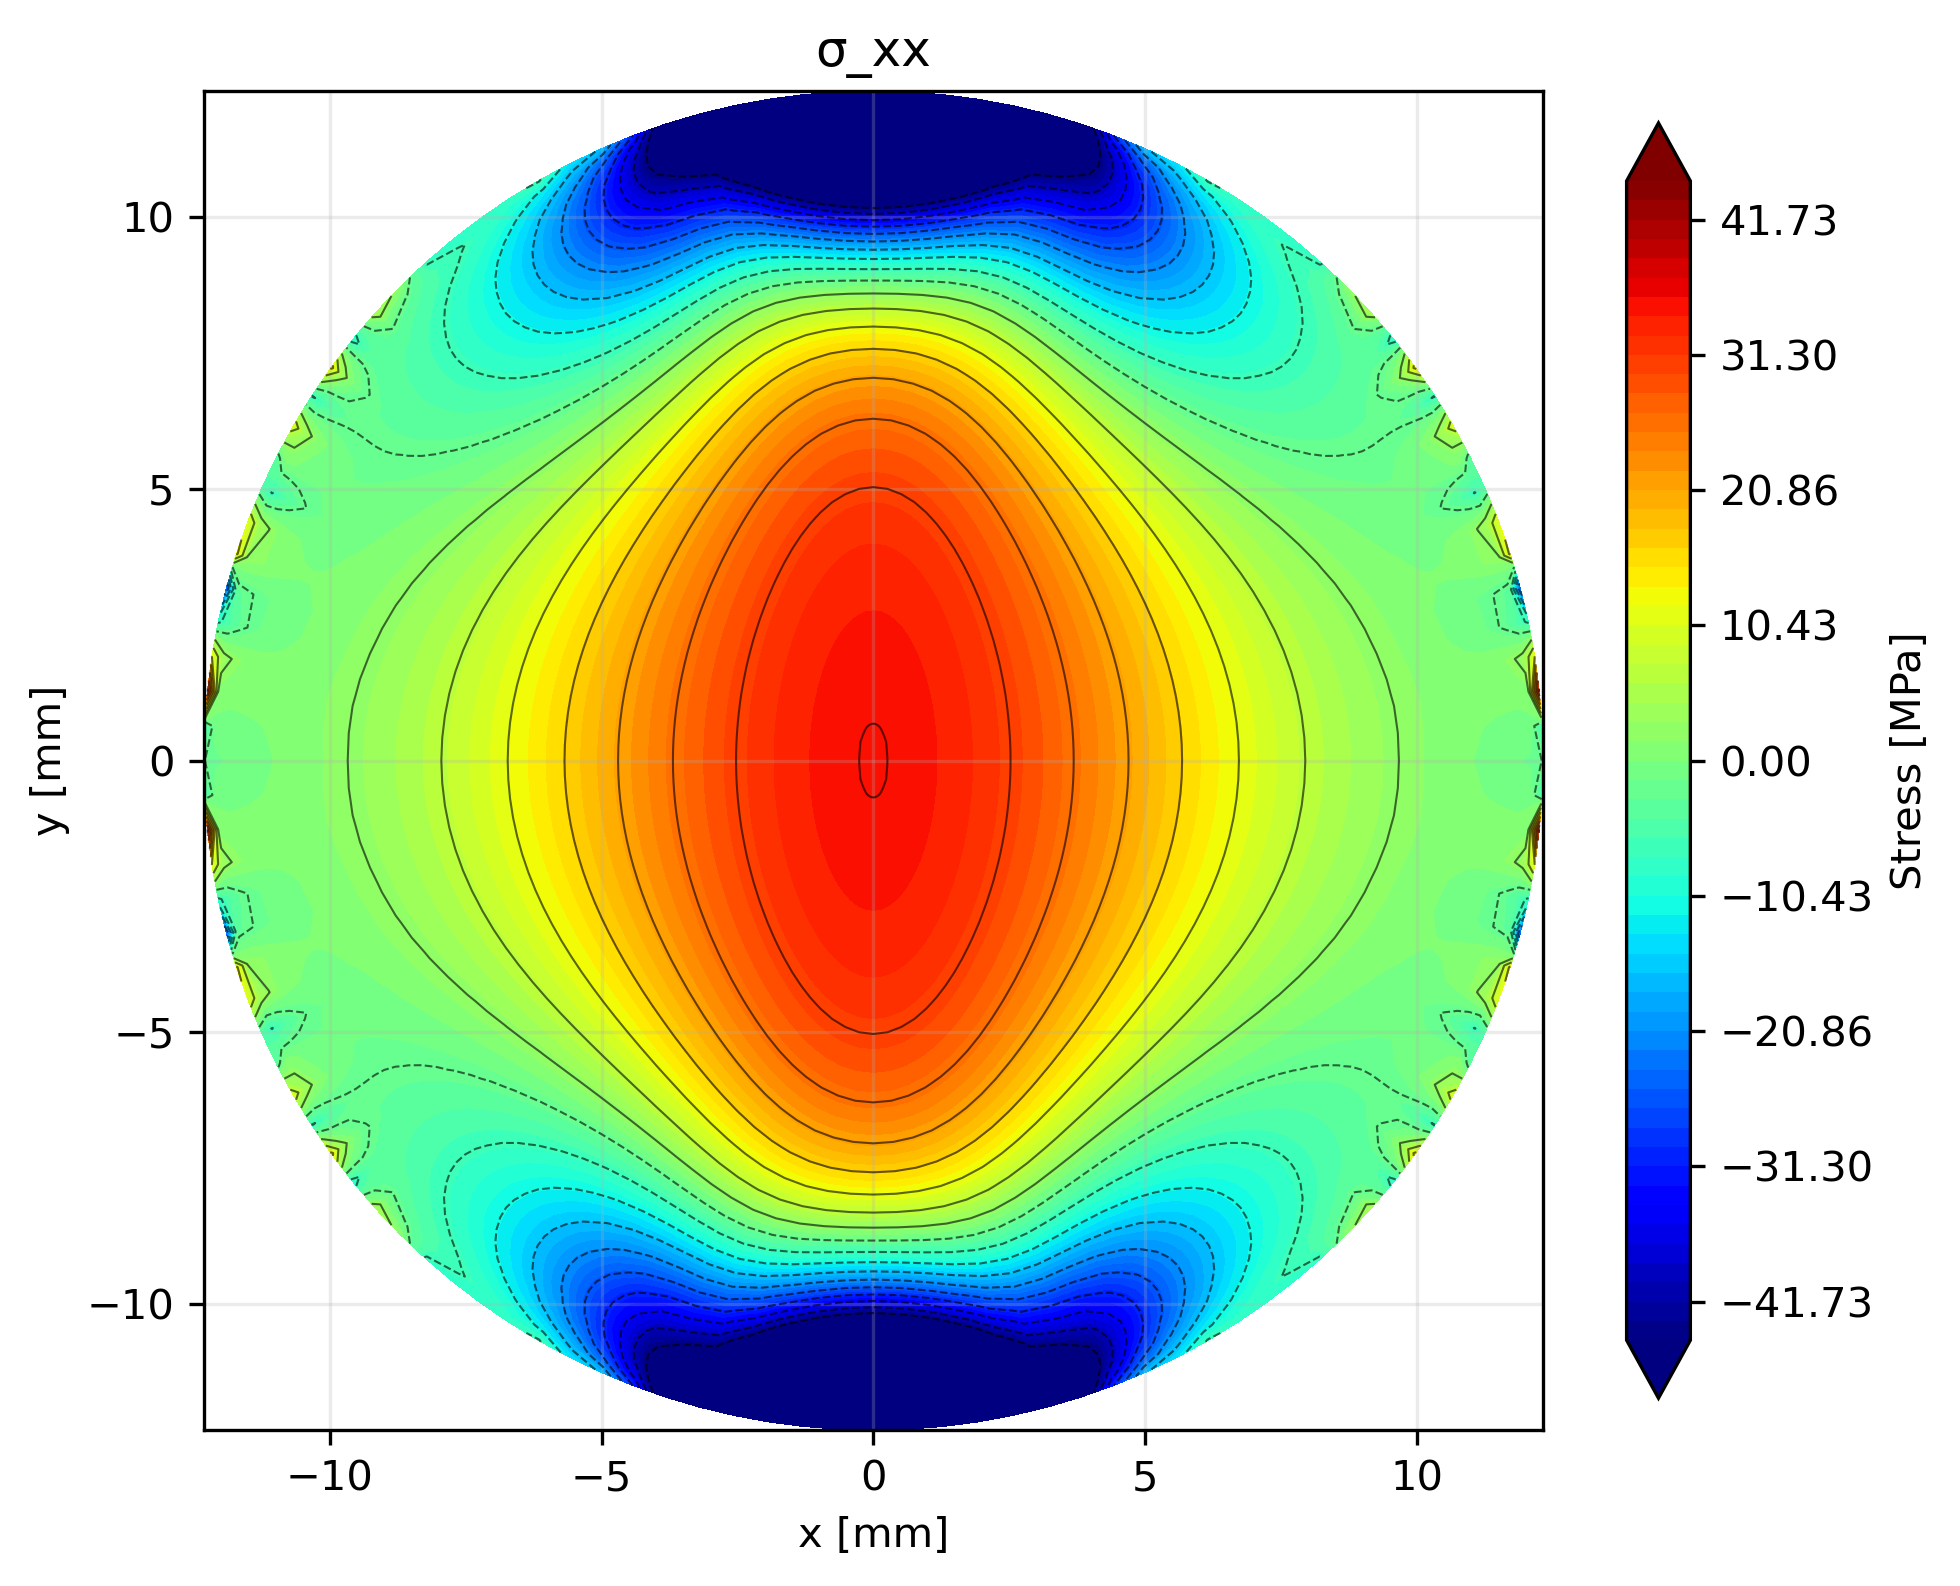

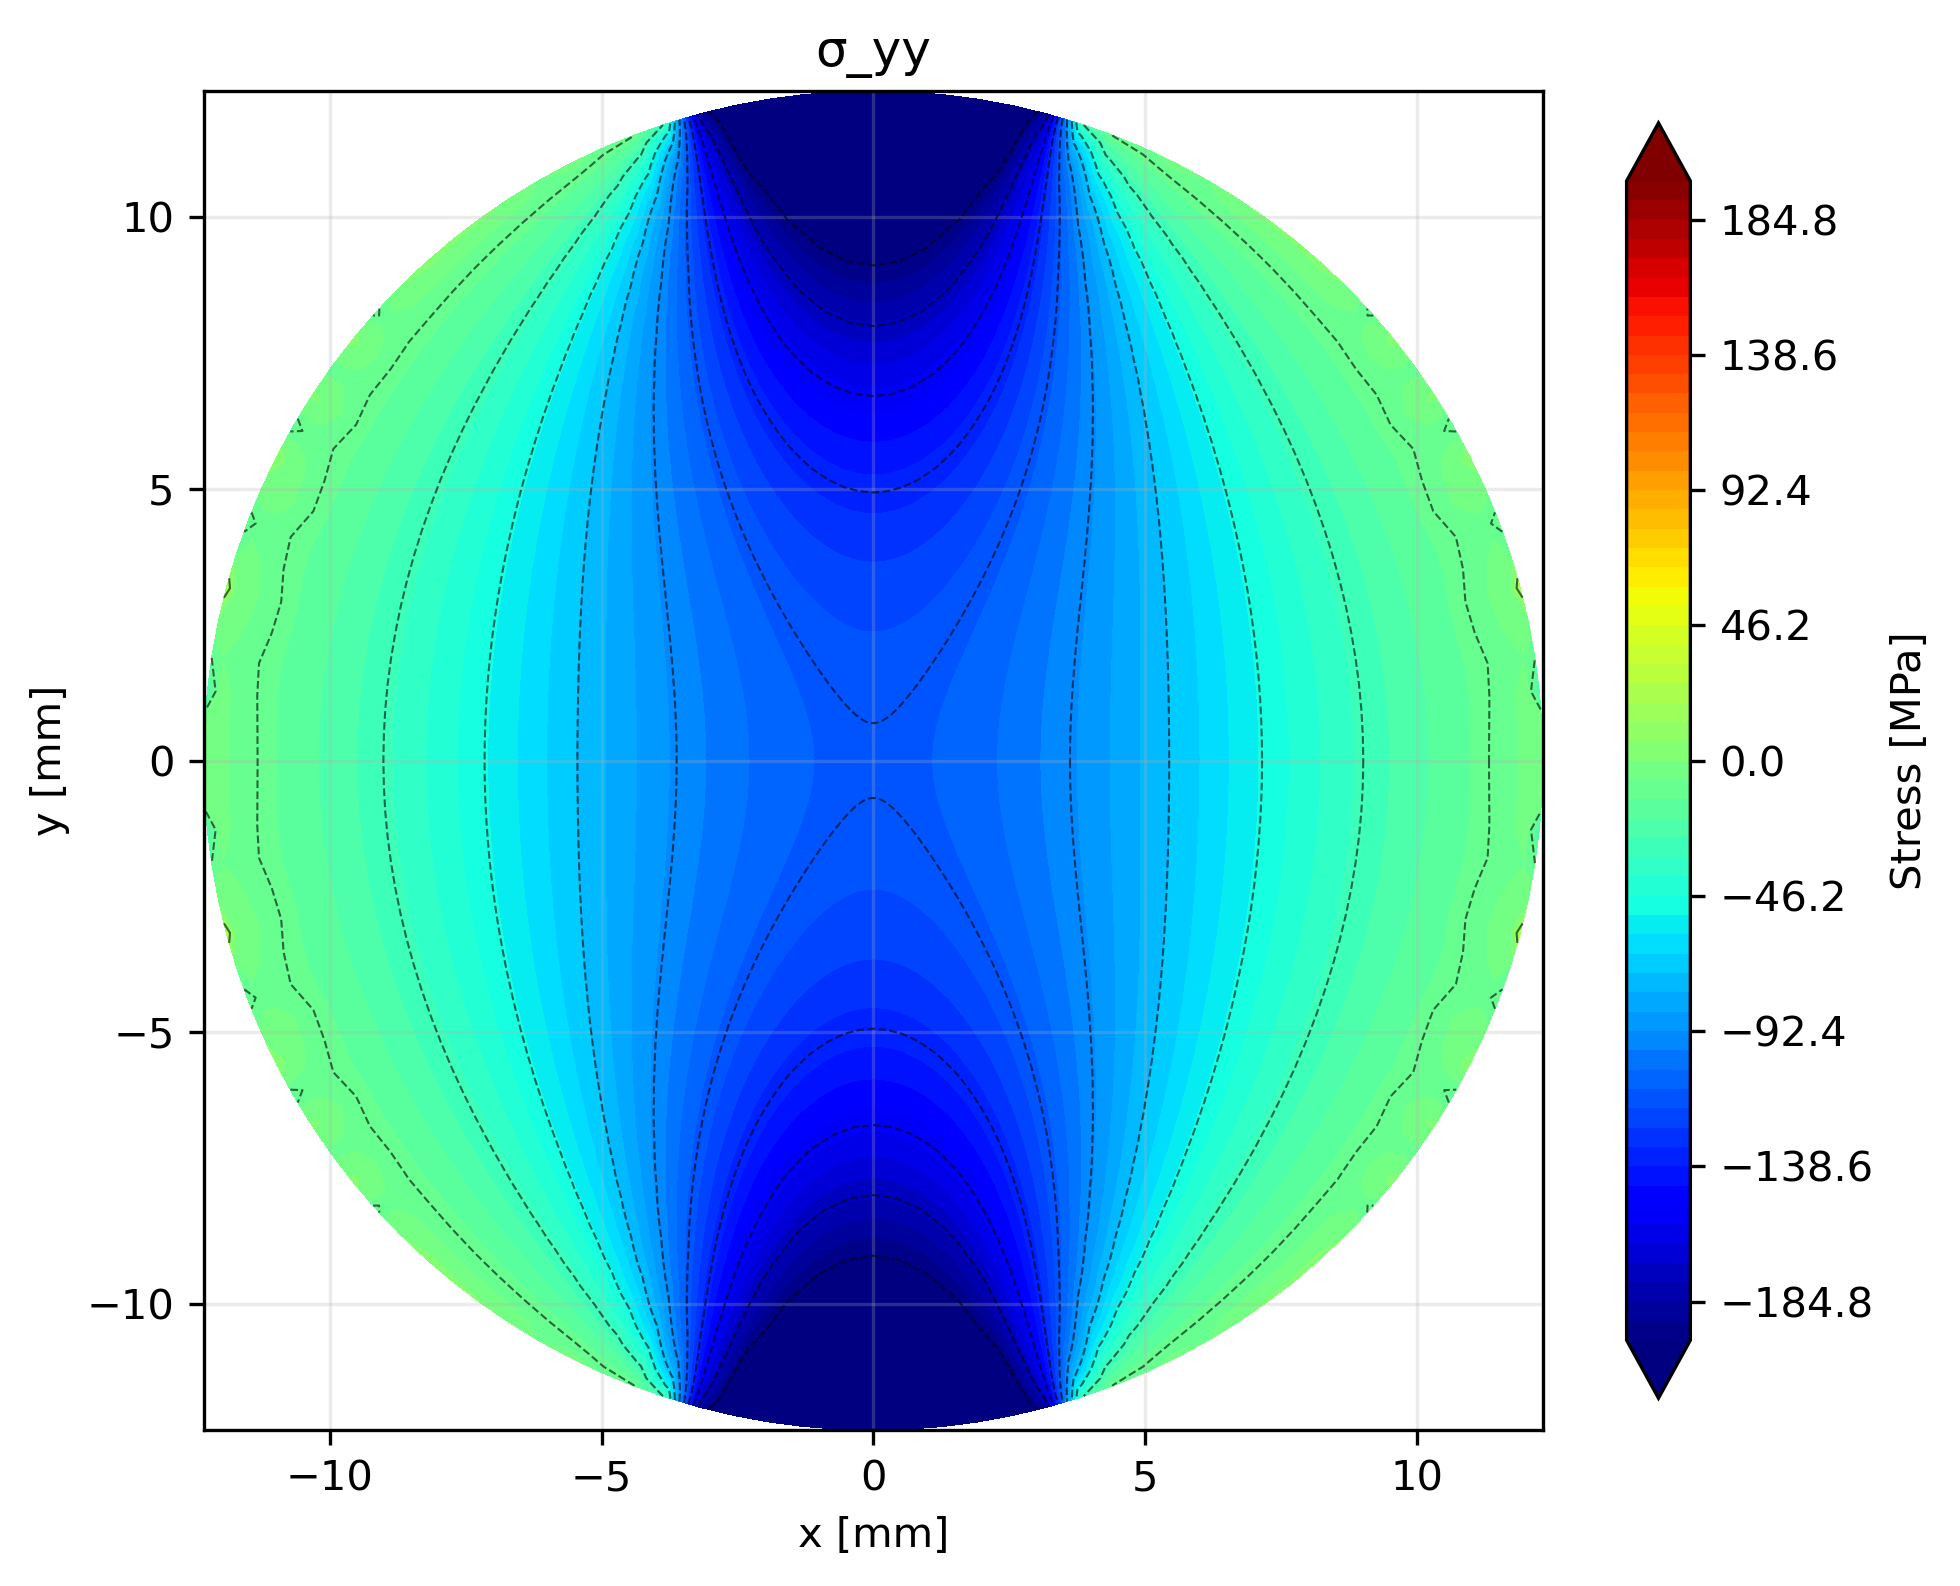

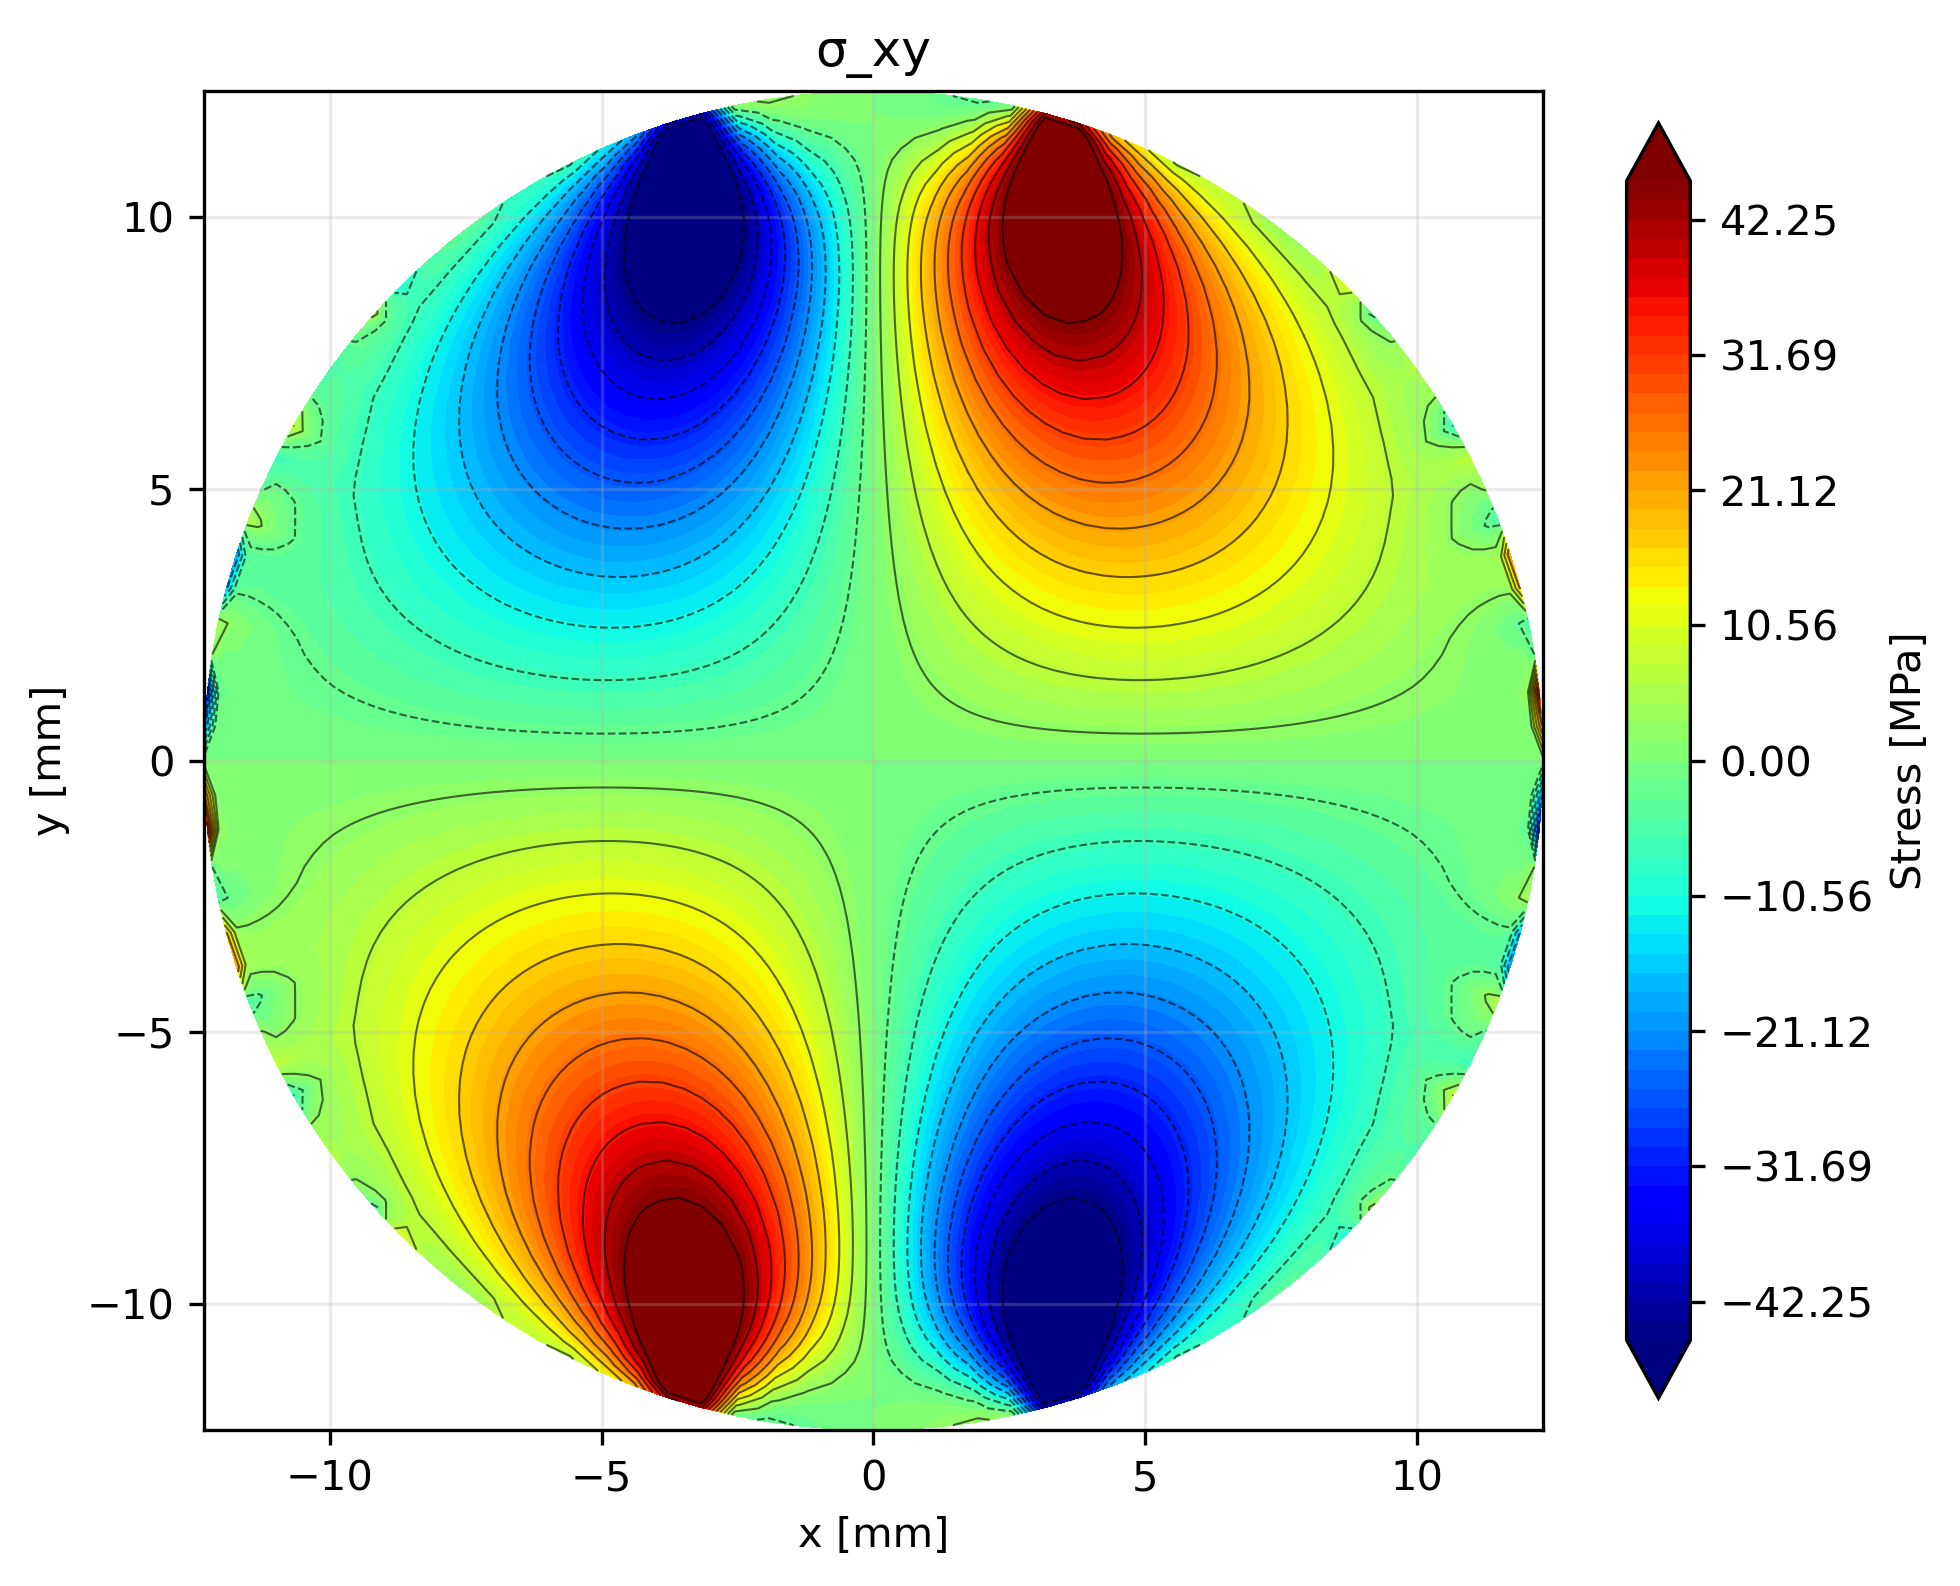

[crack_mode] auto -> half
[STEP-driver] max_steps=50 coupling=iterative bem_correction_frequency=2
[simplify] initial pass: merge aligned + snap-to-segment + intersect
[ok] Loaded network: 4 vertices, 3 edges
[solve] STEP_00 (Nv=4, Ne=3)
[discretize] merged 8 sub-threshold panels across 3 polylines (pids=[0, 1, 2], min_panel_length_ratio=1e-03)


In [ ]:
from dataclasses import replace as _dc_replace

from fracture_utils.Ubem.brazilian_disk_bem import (
    ensure_bem_field, compute_bem_brazilian_disk_field,
)
from fracture_utils.Ubem.disk_network_propagation import (
    CrackGrowthParams, run_network_growth_uncoupled, run_growth_steps,
)
from input.excel_io import save_supplementary_grid
from input.provenance import write_provenance
from fracture_utils.Ubem.disk_crack_plotting import (
    make_standard_plot_hook, plot_total_field, plot_step_metrics,
)
from fracture_utils.Ubem.coupling_blocks_v2 import (
    BEMBlockV2, compose_solver_kwargs_v2,
)
from fracture_utils.Ubem.disk_iterative_coupling import (
    compute_crack_boundary_tractions_direct,
    solve_bem_with_extra_boundary_tractions,
)
from fracture_utils.Ubem.boundary_conditions import build_boundary
from fracture_utils.Ugenerator.spanning_cluster import find_spanning_clusters


def _network_to_arrays(net):
    V = np.array([[int(v.id), float(v.x), float(v.y)] for v in net.vertices], float)
    if len(net.edges):
        C = np.array([[int(e.v0), int(e.v1)] for e in net.edges], int)
    else:
        C = np.zeros((0, 2), int)
    return V, C


def _pick_crack_mode(requested, connectivity):
    """Resolve crack_mode='auto' against current connectivity.

    'auto' returns 'full' only when the network is a single unbranched
    chain (no deg>=3 vertex, single connected component); otherwise
    'half'. Explicit 'full'/'half' returns unchanged.
    """
    mode = str(requested).lower().strip()
    if mode != "auto":
        return mode
    if connectivity is None or np.asarray(connectivity).size == 0:
        return "full"
    C = np.asarray(connectivity, int)
    if int(np.bincount(C.ravel()).max()) >= 3:
        return "half"
    parent = {}
    def _find(x):
        while parent.setdefault(x, x) != x:
            parent[x] = parent.setdefault(parent[x], parent[x])
            x = parent[x]
        return x
    for v0, v1 in C:
        a, b = _find(int(v0)), _find(int(v1))
        if a != b:
            parent[a] = b
    n_components = len({_find(int(v)) for pair in C for v in pair})
    return "half" if n_components > 1 else "full"


def _save_total_as_bem_arrays(bem_dir, Sxx_tot, Syy_tot, Sxy_tot):
    np.save(bem_dir / "Sxx.npy", np.asarray(Sxx_tot, float))
    np.save(bem_dir / "Syy.npy", np.asarray(Syy_tot, float))
    np.save(bem_dir / "Sxy.npy", np.asarray(Sxy_tot, float))


def run_disk_compression_2(cfg):
    """Brazilian-disk + crack-network coupling, Excel-driven (flat STEP model)."""
    from datetime import datetime as _datetime
    started_at = _datetime.now()
    _ts = started_at.strftime("%Y%m%d_%H%M%S")
    bem_dir = repo_root / "output" / f"{_ts}_{cfg.output_dir_name}"
    bem_dir.mkdir(parents=True, exist_ok=True)

    bem_freq = int(cfg.bem_correction_frequency)
    if cfg.coupling_method == "no_coupling":
        bem_freq = 0

    run_stats = {
        "engine": ENGINE,
        "openmp_threads": int(bem_cpp.openmp_max_threads()) if _CPP_AVAILABLE else 0,
        "bem_cpp_version": getattr(bem_cpp, "__version__", "") if _CPP_AVAILABLE else "",
        "coupling_method": cfg.coupling_method,
        "max_steps_requested": int(cfg.max_steps),
        "bem_correction_frequency": int(bem_freq),
        "bem_corrections_fired": 0,
        "termination": "in_progress",
        "n_verts_initial": int(cfg.vertices.shape[0]),
        "n_edges_initial": int(cfg.connectivity.shape[0]),
        "n_verts_final": int(cfg.vertices.shape[0]),
        "n_edges_final": int(cfg.connectivity.shape[0]),
    }

    res_last = None

    try:
        # (1) BEM baseline + polar overlay.
        # save_contours=False suppresses the legacy rect-grid contour PNGs;
        # the polar overlay below renders the baseline field on the same
        # polar/clustered mesh used by every subsequent STEP_NN plot.
        ensure_bem_field(
            cfg.disk, bem_dir,
            recompute=(not cfg.skip_bem_solve),
            show=False, save_contours=False,
        )
        save_supplementary_grid(cfg, bem_dir, always_polar=True, show=True)

        # (2) Outer boundary mesh (used by iterative BEM correction)
        boundary_mesh = build_boundary(cfg.boundary_spec)

        # (3) Plot hook (one tag per STEP)
        hook = make_standard_plot_hook(
            bem_dir=bem_dir,
            combined_out_dir=bem_dir,
            plot_params=cfg.plot,
            show_initial=cfg.plot_show_initial,
            show_cycles=cfg.plot_show_cycles,
            show_final=cfg.plot_show_final,
        )

        # (4) Solver kwargs (one-way for STEPs, direct/full-KKT for the
        # 'direct' BEM-correction path).
        bem_block = BEMBlockV2(disk=cfg.disk, out_dir=bem_dir)
        aug_payload = bem_block.build_augmented_payload(
            d_mode=cfg.aug_d_mode, gauss_n=cfg.aug_gauss_n,
        )

        def _build_kwargs(crack_mode_effective):
            base = {
                "n_crack_elements": cfg.n_crack_elements,
                "parametrization": cfg.parametrization,
                "crack_mode": crack_mode_effective,
                "junction_model": cfg.junction_model,
                "soft_eta": cfg.soft_eta,
            }
            one_way = compose_solver_kwargs_v2("one_way", base_solver_kwargs=base)
            direct = compose_solver_kwargs_v2(
                "full_kkt",
                base_solver_kwargs={
                    **base,
                    "augmented_enforce_crack_equilibrium": cfg.aug_enforce_crack_equilibrium,
                    "augmented_equilibrate": cfg.aug_equilibrate,
                    "augmented_equilibrate_cols": cfg.aug_equilibrate_cols,
                    "augmented_physical_scaling": cfg.aug_physical_scaling,
                    "augmented_scale_traction_rows": cfg.aug_scale_traction_rows,
                },
                augmented_payload=aug_payload,
                augmented_ridge_q=cfg.aug_ridge_q,
                augmented_ridge_y=cfg.aug_ridge_y,
                augmented_keep_bem_applied=cfg.aug_keep_bem_applied,
            )
            return one_way, direct

        _current_mode = _pick_crack_mode(cfg.crack_mode, cfg.connectivity)
        one_way_kwargs, direct_kwargs = _build_kwargs(_current_mode)
        if str(cfg.crack_mode).lower().strip() == "auto":
            print(f"[crack_mode] auto -> {_current_mode}")

        original_initial_vids = set(int(v) for v in cfg.vertices[:, 0])
        grow = _dc_replace(cfg.crack_growth, solver_kwargs=one_way_kwargs)

        # (5) BEM correction hook fired by run_growth_steps every K steps.
        def _bem_correction_hook(res, step):
            run_stats["bem_corrections_fired"] += 1
            if cfg.coupling_method == "iterative":
                tx_cr, ty_cr = compute_crack_boundary_tractions_direct(
                    res=res, boundary_mesh=boundary_mesh,
                )
                solve_bem_with_extra_boundary_tractions(
                    disk_params=cfg.disk, bem_dir=bem_dir,
                    tx_extra=-tx_cr, ty_extra=-ty_cr, show=False,
                )
            elif cfg.coupling_method == "direct":
                corr_dir = bem_dir / f"STEP_{step:02d}_direct_correction"
                corr_dir.mkdir(parents=True, exist_ok=True)
                grow_direct = _dc_replace(
                    cfg.crack_growth, max_cycles=0,
                    solver_kwargs=direct_kwargs,
                )
                Vg, Cg = _network_to_arrays(res.calc.network)
                res_direct = run_network_growth_uncoupled(
                    bem_dir=bem_dir, out_dir=corr_dir,
                    vertices=Vg, connectivity=Cg,
                    params=grow_direct, plot_hook=None,
                    original_initial_vertex_ids=original_initial_vids,
                    plot_params=cfg.plot,
                )
                Sxx_tot, Syy_tot, Sxy_tot = plot_total_field(
                    bem_dir=bem_dir, res=res_direct, out_dir=corr_dir,
                    tag=f"step_{step:02d}_direct",
                    params=cfg.plot, show=False,
                )
                _save_total_as_bem_arrays(bem_dir, Sxx_tot, Syy_tot, Sxy_tot)
            elif cfg.coupling_method == "no_coupling":
                pass
            else:
                raise ValueError(
                    f"Unknown coupling_method: {cfg.coupling_method!r}. "
                    f"Expected one of: no_coupling, iterative, direct."
                )

        print(
            f"[STEP-driver] max_steps={cfg.max_steps} "
            f"coupling={cfg.coupling_method} bem_correction_frequency={bem_freq}"
        )

        res_last = run_growth_steps(
            bem_dir=bem_dir, out_dir=bem_dir,
            vertices=cfg.vertices, connectivity=cfg.connectivity,
            params=grow,
            max_steps=int(cfg.max_steps),
            bem_correction_frequency=bem_freq,
            bem_correction_hook=_bem_correction_hook,
            plot_hook=hook,
            plot_params=cfg.plot,
            original_initial_vertex_ids=original_initial_vids,
        )

        V_final, C_final = _network_to_arrays(res_last.calc.network)
        run_stats["n_verts_final"] = int(V_final.shape[0])
        run_stats["n_edges_final"] = int(C_final.shape[0])
        stopped = str(getattr(res_last, "stopped_reason", "") or "")
        run_stats["termination"] = stopped if stopped else "completed"

        if cfg.stop_on_spanning_cluster:
            snapped = getattr(res_last, "snapped_vertex_ids", None) or set()
            clusters = find_spanning_clusters(
                res_last.calc.network,
                disk_R=cfg.disk.R,
                snapped_vertex_ids=snapped,
            )
            if clusters:
                n_clusters = len(clusters)
                n_boundary_pts = sum(len(b) for _, b in clusters)
                print(
                    f"[note] spanning cluster present at end of run "
                    f"({n_clusters} component(s), {n_boundary_pts} boundary vertex(es))."
                )
                if run_stats["termination"] == "completed":
                    run_stats["termination"] = "spanning_cluster_at_end"

        print(
            f"\n[done] STEP-driver run completed: "
            f"{V_final.shape[0]} verts, {C_final.shape[0]} edges"
        )

        # End-of-run alpha / Q / per-tip SIF curves.
        try:
            plot_step_metrics(getattr(res_last, "step_history", []) or [], bem_dir,
                              dpi=int(cfg.plot.dpi))
        except Exception as _pe:
            print(f"[step-metrics] skipped (error: {_pe})")

    except BaseException as _e:
        run_stats["termination"] = f"error: {type(_e).__name__}: {_e}"
        raise
    finally:
        try:
            _prov = write_provenance(
                cfg=cfg, case_xlsx=_xlsx_path, run_dir=bem_dir,
                run_stats=run_stats, started_at=started_at,
            )
            print(f"[provenance] wrote {_prov['json'].name}")
        except Exception as _pe:
            print(f"[provenance] skipped (error: {_pe})")

    # End-of-run videos: walk STEP_NN/ and stitch the per-step PNG sequences
    # into <bem_dir>/videos/*.mp4. Non-fatal on failure.
    try:
        import sys as _sys
        _tools_dir = str(repo_root / "tools")
        if _tools_dir not in _sys.path:
            _sys.path.insert(0, _tools_dir)
        from make_run_videos import make_videos as _make_videos
        _make_videos(bem_dir, fps=5)
    except Exception as _e:
        print(f"[videos] skipped (error: {_e})")

    return {"bem_dir": bem_dir, "res_last": res_last}


# --- dispatch -------------------------------------------------------
if DRY_RUN:
    print(f"DRY RUN -- run_disk_compression_2 defined but not executed.")
    print(f"Set dry_run = False in the CONFIGURATION sheet to invoke it.")
    result = None
else:
    result = run_disk_compression_2(cfg)
    print(f"Finished -- result keys: {list(result)}")
